#### Import necessary libraries

In [1]:
import re
import math
from collections import Counter
import matplotlib.pyplot as plt
from nltk.corpus import stopwords

###  Zipf's Law
Zipf's Law states that in natural language, the frequency of a word is inversely proportional to its rank in the frequency table. The most frequent word occurs about twice as often as the second most frequent, and so on.

In [2]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/aakashshrestha/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/aakashshrestha/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

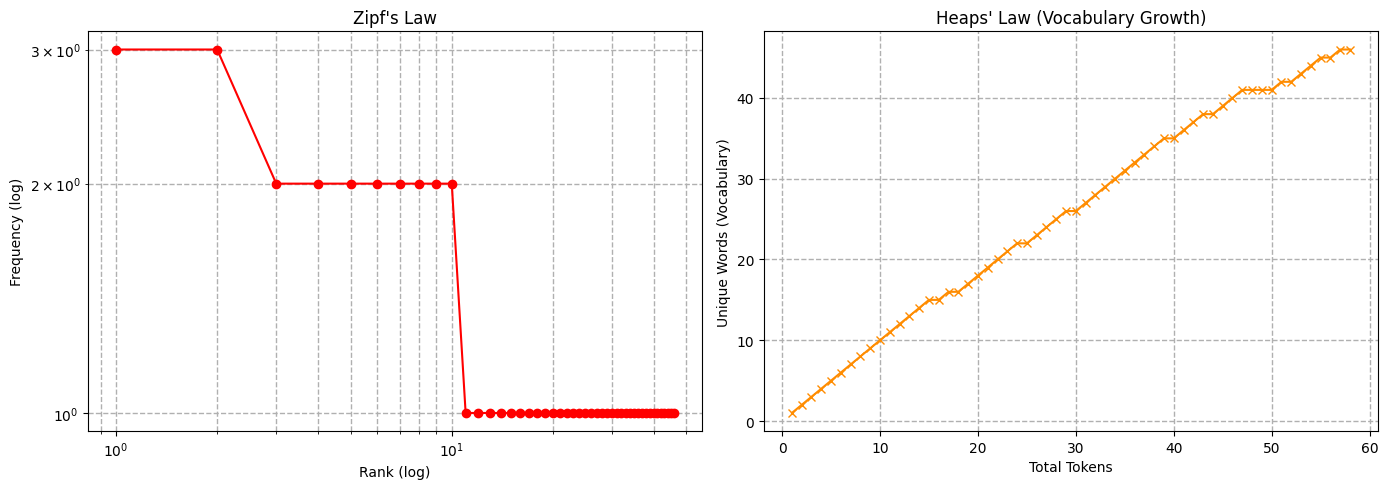

In [ ]:
text = """It’s like in the great stories, Mr. Frodo. The ones that really mattered. Full of darkness and danger, they were. And sometimes you didn’t want to know the end… because how could the end be happy?
How could the world go back to the way it was when so much bad had happened?
But in the end, it’s only a passing thing, this shadow. Even darkness must pass. A new day will come. And when the sun shines, it’ll shine out the clearer.
Those were the stories that stayed with you. That meant something, even if you were too small to understand why. But I think, Mr. Frodo, I do understand… I know now. Folk in those stories had lots of chances of turning back, only they didn’t. Because they were holding on to something."""

# Load English stop words
stop_words = set(stopwords.words('english'))
tokens = re.findall(r'\b\w+\b', text.lower())
tokens = [t for t in tokens if t not in stop_words and len(t) > 2]

# Zipf’s Law: Frequency and rank
freq = Counter(tokens)
sorted_items = sorted(freq.items(), key=lambda x: x[1], reverse=True)#-->[(,),(,)]
words, freqs = zip(*sorted_items) #unzipping
ranks = range(1, len(freqs) + 1)

# Heaps’ Law: Vocabulary growth
vocab = set()
vocab_size = []
token_counts = []

for i, word in enumerate(tokens, 1):
    vocab.add(word)
    vocab_size.append(len(vocab))
    token_counts.append(i)

# Plot both in subplots
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Zipf’s Law Plot
axs[0].loglog(ranks, freqs, marker='o', color='red')
axs[0].set_title("Zipf's Law")
axs[0].set_xlabel("Rank (log)")
axs[0].set_ylabel("Frequency (log)")
axs[0].grid(True, which='both', linestyle='--', linewidth=1)

# Heaps’ Law Plot
axs[1].plot(token_counts, vocab_size, marker='x', color='darkorange')
axs[1].set_title("Heaps' Law (Vocabulary Growth)")
axs[1].set_xlabel("Total Tokens")
axs[1].set_ylabel("Unique Words (Vocabulary)")
axs[1].grid(True, linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

### TF-IDF

In [ ]:
text = """It’s like in the great stories, Mr. Frodo. The ones that really mattered. Full of darkness and danger, they were. And sometimes you didn’t want to know the end… because how could the end be happy?
How could the world go back to the way it was when so much bad had happened?
But in the end, it’s only a passing thing, this shadow. Even darkness must pass. A new day will come. And when the sun shines, it’ll shine out the clearer.
Those were the stories that stayed with you. That meant something, even if you were too small to understand why. But I think, Mr. Frodo, I do understand… I know now. Folk in those stories had lots of chances of turning back, only they didn’t. Because they were holding on to something"""

# Split into paragraphs
documents = [p.strip() for p in text.split('\n\n') if p.strip()]

for each_doc in documents:
    print(each_doc)


It’s like in the great stories, Mr. Frodo. The ones that really mattered. Full of darkness and danger, they were. And sometimes you didn’t want to know the end… because how could the end be happy?
How could the world go back to the way it was when so much bad had happened?
But in the end, it’s only a passing thing, this shadow. Even darkness must pass. A new day will come. And when the sun shines, it’ll shine out the clearer.
Those were the stories that stayed with you. That meant something, even if you were too small to understand why. But I think, Mr. Frodo, I do understand… I know now. Folk in those stories had lots of chances of turning back, only they didn’t. Because they were holding on to something


#### Basic tokenizer and preprocessing


In [5]:
# We can have our own set of stop words
stop_words = set([
    'the', 'is', 'at', 'which', 'on', 'for', 'to', 'be', 'with', 'a', 'an', 'and', 'of', 'this', 'from', 'i', 'you',
    'in', 'it', 'that', 'just', 'your', 'have', 'has', 'as', 'are', 'was', 'were', 'but', 'by', 'not', 'or', 'so', 'if'
])  

def tokenize(text):
    tokens = re.findall(r'\b\w+\b', text.lower())
    return [t for t in tokens if t not in stop_words and len(t) > 2]

# Tokenize all docs
tokenized_docs = [tokenize(doc) for doc in documents]

for each_tokenize_doc in tokenized_docs:
    print(each_tokenize_doc)


['like', 'great', 'stories', 'frodo', 'ones', 'really', 'mattered', 'full', 'darkness', 'danger', 'they', 'sometimes', 'didn', 'want', 'know', 'end', 'because', 'how', 'could', 'end', 'happy', 'how', 'could', 'world', 'back', 'way', 'when', 'much', 'bad', 'had', 'happened', 'end', 'only', 'passing', 'thing', 'shadow', 'even', 'darkness', 'must', 'pass', 'new', 'day', 'will', 'come', 'when', 'sun', 'shines', 'shine', 'out', 'clearer', 'those', 'stories', 'stayed', 'meant', 'something', 'even', 'too', 'small', 'understand', 'why', 'think', 'frodo', 'understand', 'know', 'now', 'folk', 'those', 'stories', 'had', 'lots', 'chances', 'turning', 'back', 'only', 'they', 'didn', 'because', 'they', 'holding', 'something']


#### Calculate TF for each document

TF(term) = (Number of times the term appears in a document) / (Total number of terms in the document)

In [6]:
def compute_tf(tokens):
    tf_counter = Counter(tokens)
    total_tokens = len(tokens)
    tf = {term: count / total_tokens for term, count in tf_counter.items()}
    return tf

tf_docs = [compute_tf(doc) for doc in tokenized_docs]

for each_tf_doc in tf_docs:
    print(each_tf_doc)


{'like': 0.0125, 'great': 0.0125, 'stories': 0.0375, 'frodo': 0.025, 'ones': 0.0125, 'really': 0.0125, 'mattered': 0.0125, 'full': 0.0125, 'darkness': 0.025, 'danger': 0.0125, 'they': 0.0375, 'sometimes': 0.0125, 'didn': 0.025, 'want': 0.0125, 'know': 0.025, 'end': 0.0375, 'because': 0.025, 'how': 0.025, 'could': 0.025, 'happy': 0.0125, 'world': 0.0125, 'back': 0.025, 'way': 0.0125, 'when': 0.025, 'much': 0.0125, 'bad': 0.0125, 'had': 0.025, 'happened': 0.0125, 'only': 0.025, 'passing': 0.0125, 'thing': 0.0125, 'shadow': 0.0125, 'even': 0.025, 'must': 0.0125, 'pass': 0.0125, 'new': 0.0125, 'day': 0.0125, 'will': 0.0125, 'come': 0.0125, 'sun': 0.0125, 'shines': 0.0125, 'shine': 0.0125, 'out': 0.0125, 'clearer': 0.0125, 'those': 0.025, 'stayed': 0.0125, 'meant': 0.0125, 'something': 0.025, 'too': 0.0125, 'small': 0.0125, 'understand': 0.025, 'why': 0.0125, 'think': 0.0125, 'now': 0.0125, 'folk': 0.0125, 'lots': 0.0125, 'chances': 0.0125, 'turning': 0.0125, 'holding': 0.0125}


#### Calculate IDF for all terms


##### IDF(term) =  log( Total number of documents  / number of documents containing term ) 
---
##### IDF(term) = log((Total documents + 1) / (Documents with term + 1)) + 1

In [7]:
def compute_idf(tokenized_documents):
    N = len(tokenized_documents)
    all_terms = set(term for doc in tokenized_documents for term in doc)
    idf = {}
    for term in all_terms:
        containing_docs = sum(1 for doc in tokenized_documents if term in doc)
        idf[term] = math.log((N + 1) / (containing_docs + 1)) + 1  
    return idf

idf = compute_idf(tokenized_docs)

for each_idf_doc in tf_docs:
    print(each_idf_doc)

{'like': 0.0125, 'great': 0.0125, 'stories': 0.0375, 'frodo': 0.025, 'ones': 0.0125, 'really': 0.0125, 'mattered': 0.0125, 'full': 0.0125, 'darkness': 0.025, 'danger': 0.0125, 'they': 0.0375, 'sometimes': 0.0125, 'didn': 0.025, 'want': 0.0125, 'know': 0.025, 'end': 0.0375, 'because': 0.025, 'how': 0.025, 'could': 0.025, 'happy': 0.0125, 'world': 0.0125, 'back': 0.025, 'way': 0.0125, 'when': 0.025, 'much': 0.0125, 'bad': 0.0125, 'had': 0.025, 'happened': 0.0125, 'only': 0.025, 'passing': 0.0125, 'thing': 0.0125, 'shadow': 0.0125, 'even': 0.025, 'must': 0.0125, 'pass': 0.0125, 'new': 0.0125, 'day': 0.0125, 'will': 0.0125, 'come': 0.0125, 'sun': 0.0125, 'shines': 0.0125, 'shine': 0.0125, 'out': 0.0125, 'clearer': 0.0125, 'those': 0.025, 'stayed': 0.0125, 'meant': 0.0125, 'something': 0.025, 'too': 0.0125, 'small': 0.0125, 'understand': 0.025, 'why': 0.0125, 'think': 0.0125, 'now': 0.0125, 'folk': 0.0125, 'lots': 0.0125, 'chances': 0.0125, 'turning': 0.0125, 'holding': 0.0125}


#### Calculate TF-IDF for each doc

In [8]:
def compute_tfidf(tf, idf):
    tfidf = {term: tf_val * idf.get(term, 0) for term, tf_val in tf.items()}
    return tfidf

tfidf_docs = [compute_tfidf(tf_doc, idf) for tf_doc in tf_docs]

for each_tfidf_doc in tfidf_docs:
    print(each_tfidf_doc)


{'like': 0.0125, 'great': 0.0125, 'stories': 0.0375, 'frodo': 0.025, 'ones': 0.0125, 'really': 0.0125, 'mattered': 0.0125, 'full': 0.0125, 'darkness': 0.025, 'danger': 0.0125, 'they': 0.0375, 'sometimes': 0.0125, 'didn': 0.025, 'want': 0.0125, 'know': 0.025, 'end': 0.0375, 'because': 0.025, 'how': 0.025, 'could': 0.025, 'happy': 0.0125, 'world': 0.0125, 'back': 0.025, 'way': 0.0125, 'when': 0.025, 'much': 0.0125, 'bad': 0.0125, 'had': 0.025, 'happened': 0.0125, 'only': 0.025, 'passing': 0.0125, 'thing': 0.0125, 'shadow': 0.0125, 'even': 0.025, 'must': 0.0125, 'pass': 0.0125, 'new': 0.0125, 'day': 0.0125, 'will': 0.0125, 'come': 0.0125, 'sun': 0.0125, 'shines': 0.0125, 'shine': 0.0125, 'out': 0.0125, 'clearer': 0.0125, 'those': 0.025, 'stayed': 0.0125, 'meant': 0.0125, 'something': 0.025, 'too': 0.0125, 'small': 0.0125, 'understand': 0.025, 'why': 0.0125, 'think': 0.0125, 'now': 0.0125, 'folk': 0.0125, 'lots': 0.0125, 'chances': 0.0125, 'turning': 0.0125, 'holding': 0.0125}


#### Show top terms in the first paragraph

In [9]:
first_doc_tfidf = tfidf_docs[0]
top_terms = sorted(first_doc_tfidf.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top terms in the first paragraph (from scratch TF-IDF):")
for term, score in top_terms:
    print(f"{term}: {score:.4f}")


Top terms in the first paragraph (from scratch TF-IDF):
stories: 0.0375
they: 0.0375
end: 0.0375
frodo: 0.0250
darkness: 0.0250
didn: 0.0250
know: 0.0250
because: 0.0250
how: 0.0250
could: 0.0250


In [10]:
# Show in a datafrrame
import pandas as pd

all_tokens = [token for doc in tokenized_docs for token in doc]

corpus_tf = compute_tf(all_tokens)

corpus_tfidf = compute_tfidf(corpus_tf, idf)

# Create a DataFrame
import pandas as pd
df_corpus = pd.DataFrame({
    'Term': list(corpus_tf.keys()),
    'TF': [round(corpus_tf[t], 4) for t in corpus_tf],
    'IDF': [round(idf[t], 4) for t in corpus_tf],
    'TF-IDF': [round(corpus_tfidf[t], 4) for t in corpus_tf]
})

df_corpus = df_corpus.sort_values(by='TF-IDF', ascending=False)

# Show top 20 terms in the whole corpus
print("Top terms in the whole corpus:")
print("_"*40)
print(df_corpus.head(20))


Top terms in the whole corpus:
________________________________________
          Term      TF  IDF  TF-IDF
2      stories  0.0375  1.0  0.0375
10        they  0.0375  1.0  0.0375
15         end  0.0375  1.0  0.0375
18       could  0.0250  1.0  0.0250
44       those  0.0250  1.0  0.0250
23        when  0.0250  1.0  0.0250
26         had  0.0250  1.0  0.0250
21        back  0.0250  1.0  0.0250
50  understand  0.0250  1.0  0.0250
28        only  0.0250  1.0  0.0250
17         how  0.0250  1.0  0.0250
16     because  0.0250  1.0  0.0250
14        know  0.0250  1.0  0.0250
12        didn  0.0250  1.0  0.0250
8     darkness  0.0250  1.0  0.0250
32        even  0.0250  1.0  0.0250
3        frodo  0.0250  1.0  0.0250
47   something  0.0250  1.0  0.0250
46       meant  0.0125  1.0  0.0125
43     clearer  0.0125  1.0  0.0125
